## **Loan Default Prediction**
Predicts the probability that a loan will default (be **Charged Off**) based on borrower and loan characteristics known **at application time**.

**Pipeline:** Data Cleaning &rarr; EDA &rarr; Feature Engineering &rarr; Model Training &rarr; Prediction Pipeline

## **Key features used for modeling**
- **Loan terms:** `loan_amnt`, `term`, `int_rate`, `installment`, `grade`, `sub_grade`
- **Borrower profile:** `emp_length`, `home_ownership`, `annual_inc`, `verification_status`
- **Loan context:** `purpose`, `addr_state`, `dti`
- **Credit history:** `delinq_2yrs`, `inq_last_6mths`, `open_acc`, `pub_rec`, `revol_bal`, `revol_util`, `total_acc`, `pub_rec_bankruptcies`, `mths_since_last_delinq`
- **Dates:** `earliest_cr_line`, `issue_d` -> used to engineer credit history length

Columns describing what happened **after** the loan was issued (`total_pymnt`, `total_rec_prncp`, `recoveries`,
`out_prncp`, `last_pymnt_amnt`, etc.) are excluded from modeling - they would leak the answer.

# **SECTION 1: SETUP**

In [ ]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
%matplotlib inline

In [ ]:
# Load raw dataset
df = pd.read_csv("data/loan.csv", low_memory=False)
print("Raw shape:", df.shape)
df.head()

Raw shape: (39717, 111)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.00,36 months,10.65%,162.87,B,B2,NaN,10+ years,RENT,24000.00,Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0,Jan-85,1,NaN,NaN,3,0,13648,83.70%,9,f,0.00,0.00,5863.16,5833.84,5000.00,863.16,0.00,0.00,0.00,Jan-15,171.62,NaN,May-16,0.00,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.00,60 months,15.27%,59.83,C,C4,Ryder,< 1 year,RENT,30000.00,Source Verified,Dec-11,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0,Apr-99,5,NaN,NaN,3,0,1687,9.40%,4,f,0.00,0.00,1008.71,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.00,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.00,36 months,15.96%,84.33,C,C5,NaN,10+ years,RENT,12252.00,Not Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,real estate business,606xx,IL,8.72,0,Nov-01,2,NaN,NaN,2,0,2956,98.50%,10,f,0.00,0.00,3005.67,3005.67,2400.00,605.67,0.00,0.00,0.00,Jun-14,649.91,NaN,May-16,0.00,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.00,36 months,13.49%,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.00,Source Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0,Feb-96,1,35.00,NaN,10,0,5598,21%,37,f,0.00,0.00,12231.89,12231.89,10000.00,2214.92,16.97,0.00,0.00,Jan-15,357.48,NaN,Apr-16,0.00,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(74), int64(13), object(24)
memory usage: 33.6+ MB


In [ ]:
# Percentage of each loan status
df["loan_status"].value_counts(normalize=True) * 100

loan_status
Fully Paid    82.96
Charged Off   14.17
Current        2.87
Name: proportion, dtype: float64

`Current Loans` haven't reached a final outcome yet, so they carry no `Fully Paid` / `Charged Off` label, therefore it will be dropped.

In [ ]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
print(df["loan_status"].value_counts())
print(df.shape)

loan_status
Fully Paid     32950
Charged Off     5627
Name: count, dtype: int64
(38577, 111)


# **SECTION 2: DATA CLEANING**
1. Remove duplicate records
2. Remove leakage / irrelevant / redundant columns (IDs, URLs, post-outcome fields)
3. Handle missing values (indicators, median/mode imputation, drop high-missing columns)
4. Convert data types (dates, percentages)
5. Detect and treat outliers (IQR method)
6. Standardize categorical text
7. Check for invalid values

#### 1.1 Remove duplicate records

In [ ]:
before = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {before - df.shape[0]} duplicate rows -> shape: {df.shape}")

Removed 0 duplicate rows -> shape: (38577, 111)


#### 1.2 Remove leakage, irrelevant, and redundant columns
These fall into three groups:
- **Identifiers / free text / links** - no predictive value: `id`, `member_id`, `url`, `desc`, `emp_title`, `title`, `zip_code`
- **Outcome leakage** - only known *after* the loan is issued and resolved, so they would let the model "see the future":
  `funded_amnt`, `funded_amnt_inv`, `out_prncp`, `out_prncp_inv`, `total_pymnt`, `total_pymnt_inv`, `total_rec_prncp`,
  `total_rec_int`, `total_rec_late_fee`, `recoveries`, `collection_recovery_fee`, `last_pymnt_d`, `last_pymnt_amnt`,
  `next_pymnt_d`, `last_credit_pull_d`, `collections_12_mths_ex_med`
- **Constant / no variance columns** - a single unique value across the whole dataset: `application_type`, `policy_code`, `pymnt_plan`

In [ ]:
id_text_cols = ["id", "member_id", "url", "desc", "emp_title", "title", "zip_code"]

leakage_cols = [
    "funded_amnt", "funded_amnt_inv",
    "out_prncp", "out_prncp_inv",
    "total_pymnt", "total_pymnt_inv", "total_rec_prncp",
    "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt",
    "next_pymnt_d", "last_credit_pull_d",
    "collections_12_mths_ex_med",
]

# columns with a single unique value carry no signal for the model
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print("Constant columns found:", constant_cols)

drop_cols = id_text_cols + leakage_cols + constant_cols
df = df.drop(columns=drop_cols, errors="ignore")
print(f"Dropped {len(drop_cols)} columns -> shape: {df.shape}")

Constant columns found: ['pymnt_plan', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'next_pymnt_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 

#### 1.3 Missing values

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = (
    pd.DataFrame({"Missing": missing, "Percent": missing_pct})
    .query("Missing > 0")
    .sort_values("Missing", ascending=False)
)
missing_report

,Missing,Percent
mths_since_last_record,35837,92.90
mths_since_last_delinq,24905,64.56
emp_length,1033,2.68
pub_rec_bankruptcies,697,1.81
revol_util,50,0.13


Two credit-history columns (`mths_since_last_delinq`, `mths_since_last_record`) are missing precisely when a borrower
has *no* recorded delinquency/public record - that absence is itself informative, so a **missing-value indicator** is
created for each before any imputation happens.

In [ ]:
df["has_mths_since_last_delinq"] = df["mths_since_last_delinq"].isna().astype(int)
df["has_mths_since_last_record"] = df["mths_since_last_record"].isna().astype(int)

# mths_since_last_delinq (~65% missing) is informative enough to keep - impute with the median
df["mths_since_last_delinq"] = df["mths_since_last_delinq"].fillna(df["mths_since_last_delinq"].median())

In [ ]:
# Drop remaining columns that are still missing more than 50% of their values

missing_pct_now = df.isnull().mean() * 100
high_missing_cols = missing_pct_now[missing_pct_now > 50].index.tolist()

df = df.drop(columns=high_missing_cols)
print(f"Dropped {len(high_missing_cols)} columns with >50% missing values, incl. mths_since_last_record")
print("Shape now:", df.shape)

Dropped 1 columns with >50% missing values, incl. mths_since_last_record
Shape now: (38577, 27)


In [ ]:
# Numeric: fill remaining gaps with the column median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical: fill remaining gaps with the column mode
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    mode = df[col].mode()
    if not mode.empty:
        df[col] = df[col].fillna(mode.iloc[0])

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


#### 1.4 Convert data types

In [ ]:
# Dates
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%y", errors="coerce")
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%y", errors="coerce")

# Percentage columns stored as strings, e.g. "10.65%"
for col in ["int_rate", "revol_util"]:
    df[col] = df[col].astype(str).str.replace("%", "", regex=False).astype(float)

# Loan term stored as "36 months" / "60 months" -> integer months
df["term"] = df["term"].astype(str).str.extract(r"(\d+)").astype(int)

df[["issue_d", "earliest_cr_line", "int_rate", "revol_util", "term"]].head()

,issue_d,earliest_cr_line,int_rate,revol_util,term
0,2011-12-01,1985-01-01,10.65,83.70,36
1,2011-12-01,1999-04-01,15.27,9.40,60
2,2011-12-01,2001-11-01,15.96,98.50,36
3,2011-12-01,1996-02-01,13.49,21.00,36
5,2011-12-01,2004-11-01,7.90,28.30,36


#### 1.5 Detect and treat outliers (IQR method)

In [ ]:
outlier_cols = ["annual_inc", "loan_amnt", "dti", "int_rate"]

for col in outlier_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    before = df.shape[0]
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    print(f"{col:12s} removed {before - df.shape[0]:5d} rows outside [{lower:,.2f}, {upper:,.2f}]")

print("\nShape after outlier removal:", df.shape)

annual_inc   removed  1762 rows outside [-23,000.00, 145,000.00]
loan_amnt    removed   550 rows outside [-10,000.00, 30,000.00]
dti          removed     0 rows outside [-7.24, 34.25]
int_rate     removed    67 rows outside [0.85, 22.32]

Shape after outlier removal: (36198, 27)



loan_amnt    removed   550 rows outside [-10,000.00, 30,000.00]
dti          removed     0 rows outside [-7.24, 34.25]
int_rate     removed    67 rows outside [0.85, 22.32]

Shape after outlier removal: (36198, 27)


#### 1.6 Standardize categorical text

In [ ]:
text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].str.strip().str.lower()

df[text_cols].head(3)

,grade,sub_grade,emp_length,home_ownership,verification_status,loan_status,purpose,addr_state
0,b,b2,10+ years,rent,verified,fully paid,credit_card,az
1,c,c4,< 1 year,rent,source verified,charged off,car,ga
2,c,c5,10+ years,rent,not verified,fully paid,small_business,il


#### 1.7 Check for invalid values

In [ ]:
before = df.shape[0]
df = df[(df["annual_inc"] >= 0) & (df["loan_amnt"] >= 0) & (df["int_rate"] >= 0) & (df["dti"] >= 0)]
print(f"Removed {before - df.shape[0]} rows with invalid negative values -> shape: {df.shape}")

Removed 0 rows with invalid negative values -> shape: (36198, 27)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36198 entries, 0 to 39716
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   loan_amnt                   36198 non-null  int64         
 1   term                        36198 non-null  int64         
 2   int_rate                    36198 non-null  float64       
 3   installment                 36198 non-null  float64       
 4   grade                       36198 non-null  object        
 5   sub_grade                   36198 non-null  object        
 6   emp_length                  36198 non-null  object        
 7   home_ownership              36198 non-null  object        
 8   annual_inc                  36198 non-null  float64       
 9   verification_status         36198 non-null  object        
 10  issue_d                     36198 non-null  datetime64[ns]
 11  loan_status                 36198 non-null  object        


# **SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)**
1. What is the class balance of the target (`loan_status`)?
2. Does annual income influence loan repayment?
3. Does employment length influence loan repayment?
4. Does home ownership affect loan repayment?
5. Does loan grade influence loan repayment?
6. Does interest rate affect loan repayment?
7. Does loan purpose influence loan repayment?
8. Which states have the highest default counts?
9. What is the distribution of loan amount / interest rate?
10. Which numeric variables are most correlated with each other?
11. How has loan volume changed over time?

All charts are saved to `plots/`.

In [ ]:
# Project folder structure 

PROJECT_ROOT = Path.cwd()

CLEAN_DIR   = PROJECT_ROOT / "clean_data"
PLOTS_DIR   = PROJECT_ROOT / "plots"
MODELS_DIR  = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
SCRIPT_DIR  = PROJECT_ROOT / "script"

for d in [CLEAN_DIR, PLOTS_DIR, MODELS_DIR, REPORTS_DIR, SCRIPT_DIR]:
    d.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
for d in [CLEAN_DIR, PLOTS_DIR, MODELS_DIR, REPORTS_DIR, SCRIPT_DIR]:
    print(" -", d.name + "/")

Project root: C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\Loan_Prediction_Project
 - clean_data/
 - plots/
 - models/
 - reports/
 - script/


In [ ]:
def savefig(name):
    plt.savefig(PLOTS_DIR / name, dpi=300, bbox_inches="tight")

### 1. Target class balance

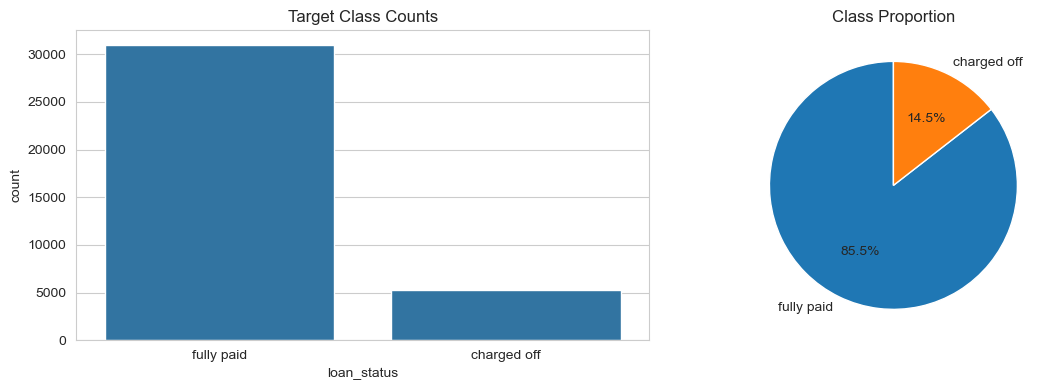

Class balance (%):
loan_status
fully paid    85.52
charged off   14.48
Name: count, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df["loan_status"].value_counts()
sns.countplot(x="loan_status", data=df, ax=axes[0])
axes[0].set_title("Target Class Counts")

axes[1].pie(target_counts, labels=target_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Class Proportion")

plt.tight_layout()
savefig("01_target_class_balance.png")
plt.show()

print("Class balance (%):")
print((target_counts / len(df) * 100).round(2))

### 2. Annual income vs loan repayment

In [ ]:
# annual income
df["annual_inc"].value_counts()

annual_inc
60000.00     1449
50000.00     1027
40000.00      852
45000.00      810
30000.00      808
             ... 
67588.00        1
134400.00       1
47940.00        1
126132.00       1
27376.00        1
Name: count, Length: 4766, dtype: int64

In [ ]:
df.groupby(["annual_inc", "loan_status"])["loan_status"].count()

annual_inc  loan_status
4000.00     fully paid      1
4080.00     charged off     1
4200.00     fully paid      2
4800.00     charged off     1
            fully paid      3
                           ..
144600.00   fully paid      1
144996.00   fully paid      3
144997.00   fully paid      1
145000.00   charged off     2
            fully paid     55
Name: loan_status, Length: 5347, dtype: int64

In [ ]:
ann_inc_loan_status = df.groupby(["annual_inc", "loan_status"])["loan_status"].count().unstack()

ann_inc_loan_status

loan_status,charged off,fully paid
annual_inc,,
4000.00,NaN,1.00
4080.00,1.00,NaN
4200.00,NaN,2.00
4800.00,1.00,3.00
4888.00,NaN,1.00
...,...,...
144500.00,1.00,2.00
144600.00,NaN,1.00
144996.00,NaN,3.00


In [ ]:
# filling the Nan to 0
ann_inc_loan_status = df.groupby(["annual_inc", "loan_status"])["loan_status"].count().unstack().fillna(0)

ann_inc_loan_status

loan_status,charged off,fully paid
annual_inc,,
4000.00,0.00,1.00
4080.00,1.00,0.00
4200.00,0.00,2.00
4800.00,1.00,3.00
4888.00,0.00,1.00
...,...,...
144500.00,1.00,2.00
144600.00,0.00,1.00
144996.00,0.00,3.00


In [ ]:
df["loan_status"].unique()

array(['fully paid', 'charged off'], dtype=object)

In [ ]:
# add total to the column
ann_inc_loan_status["Total"] = (ann_inc_loan_status["fully paid"] + ann_inc_loan_status["charged off"])

ann_inc_loan_status

loan_status,charged off,fully paid,Total
annual_inc,,,
4000.00,0.00,1.00,1.00
4080.00,1.00,0.00,1.00
4200.00,0.00,2.00,2.00
4800.00,1.00,3.00,4.00
4888.00,0.00,1.00,1.00
...,...,...,...
144500.00,1.00,2.00,3.00
144600.00,0.00,1.00,1.00
144996.00,0.00,3.00,3.00


In [ ]:
# getting approval percentage of fully paid
ann_inc_loan_status["Approval_%"] = ann_inc_loan_status["fully paid"] / ann_inc_loan_status["Total"] * 100

ann_inc_loan_status

loan_status,charged off,fully paid,Total,Approval_%
annual_inc,,,,
4000.00,0.00,1.00,1.00,100.00
4080.00,1.00,0.00,1.00,0.00
4200.00,0.00,2.00,2.00,100.00
4800.00,1.00,3.00,4.00,75.00
4888.00,0.00,1.00,1.00,100.00
...,...,...,...,...
144500.00,1.00,2.00,3.00,66.67
144600.00,0.00,1.00,1.00,100.00
144996.00,0.00,3.00,3.00,100.00


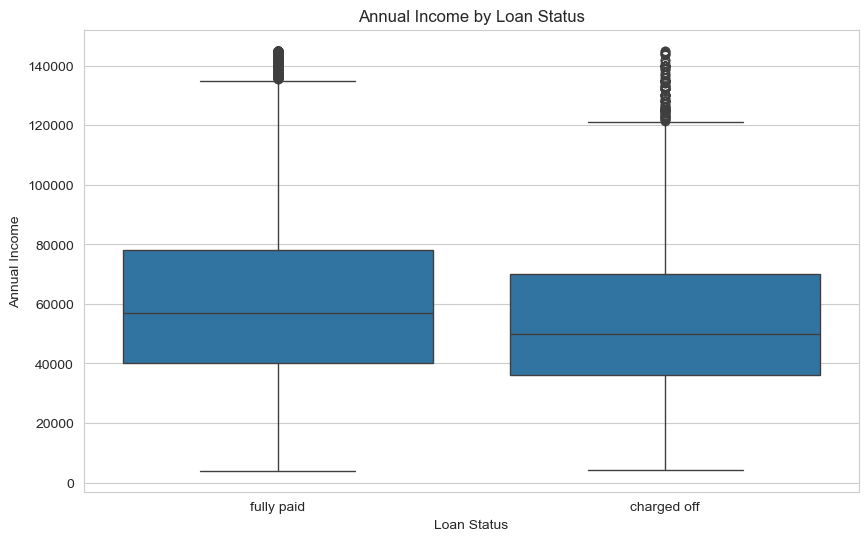

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="loan_status", y="annual_inc")
plt.title("Annual Income by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")
savefig("02_annual_income_vs_loan_status.png")
plt.show()

### 3. Employment length vs loan repayment

In [ ]:
# employment length
df["emp_length"].value_counts()

emp_length
10+ years    8695
< 1 year     4302
2 years      4078
3 years      3784
4 years      3169
1 year       3031
5 years      3006
6 years      2052
7 years      1618
8 years      1318
9 years      1145
Name: count, dtype: int64

In [ ]:
df.groupby(["emp_length", "loan_status"])["loan_status"].count()

emp_length  loan_status
1 year      charged off     443
            fully paid     2588
10+ years   charged off    1423
            fully paid     7272
2 years     charged off     537
            fully paid     3541
3 years     charged off     513
            fully paid     3271
4 years     charged off     431
            fully paid     2738
5 years     charged off     428
            fully paid     2578
6 years     charged off     288
            fully paid     1764
7 years     charged off     243
            fully paid     1375
8 years     charged off     184
            fully paid     1134
9 years     charged off     149
            fully paid      996
< 1 year    charged off     602
            fully paid     3700
Name: loan_status, dtype: int64

In [ ]:
emp_lenght_status = df.groupby(["emp_length", "loan_status"])["loan_status"].count().unstack()

emp_lenght_status

loan_status,charged off,fully paid
emp_length,,
1 year,443,2588
10+ years,1423,7272
2 years,537,3541
3 years,513,3271
4 years,431,2738
5 years,428,2578
6 years,288,1764
7 years,243,1375
8 years,184,1134


In [ ]:
emp_lenght_status["Total"] = (emp_lenght_status["charged off"] + emp_lenght_status["fully paid"])

emp_lenght_status

loan_status,charged off,fully paid,Total
emp_length,,,
1 year,443,2588,3031
10+ years,1423,7272,8695
2 years,537,3541,4078
3 years,513,3271,3784
4 years,431,2738,3169
5 years,428,2578,3006
6 years,288,1764,2052
7 years,243,1375,1618
8 years,184,1134,1318


In [ ]:
# approval percentage of fully paid
emp_lenght_status["Approval %"] = emp_lenght_status["fully paid"] / emp_lenght_status["Total"] * 100

emp_lenght_status

loan_status,charged off,fully paid,Total,Approval %
emp_length,,,,
1 year,443,2588,3031,85.38
10+ years,1423,7272,8695,83.63
2 years,537,3541,4078,86.83
3 years,513,3271,3784,86.44
4 years,431,2738,3169,86.40
5 years,428,2578,3006,85.76
6 years,288,1764,2052,85.96
7 years,243,1375,1618,84.98
8 years,184,1134,1318,86.04


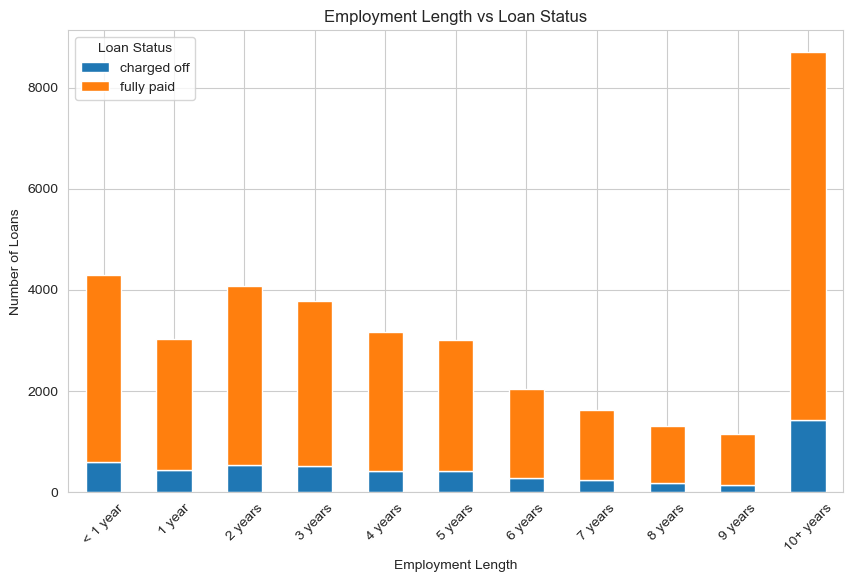

In [ ]:
emp_order = ["< 1 year"] + [f"{i} year" + ("s" if i > 1 else "") for i in range(1, 10)] + ["10+ years"]
emp_order = [e for e in emp_order if e in df["emp_length"].unique()]

ax = (
    df.groupby(["emp_length", "loan_status"])["loan_status"]
    .count()
    .unstack()
    .reindex(emp_order)
    .plot(kind="bar", stacked=True, figsize=(10, 6))
)
plt.title("Employment Length vs Loan Status")
plt.xlabel("Employment Length")
plt.ylabel("Number of Loans")
plt.legend(title="Loan Status")
plt.xticks(rotation=45)
savefig("03_employment_length_vs_loan_status.png")
plt.show()

### 4. Home ownership vs loan repayment

In [ ]:
df["home_ownership"].value_counts()

home_ownership
rent        17883
mortgage    15394
own          2825
other          93
none            3
Name: count, dtype: int64

In [ ]:
df.groupby(["home_ownership", "loan_status"])["loan_status"].count()

home_ownership  loan_status
mortgage        charged off     2088
                fully paid     13306
none            fully paid         3
other           charged off       17
                fully paid        76
own             charged off      424
                fully paid      2401
rent            charged off     2712
                fully paid     15171
Name: loan_status, dtype: int64

In [ ]:
df.groupby(["home_ownership", "loan_status"])["loan_status"].count().unstack()

loan_status,charged off,fully paid
home_ownership,,
mortgage,2088.00,13306.00
none,NaN,3.00
other,17.00,76.00
own,424.00,2401.00
rent,2712.00,15171.00


In [ ]:
home_ownership_status = df.groupby(["home_ownership", "loan_status"])["loan_status"].count().unstack().fillna(0)

home_ownership_status

loan_status,charged off,fully paid
home_ownership,,
mortgage,2088.00,13306.00
none,0.00,3.00
other,17.00,76.00
own,424.00,2401.00
rent,2712.00,15171.00


In [ ]:
home_ownership_status["Total"] = (home_ownership_status["fully paid"] + home_ownership_status["charged off"])

home_ownership_status

loan_status,charged off,fully paid,Total
home_ownership,,,
mortgage,2088.00,13306.00,15394.00
none,0.00,3.00,3.00
other,17.00,76.00,93.00
own,424.00,2401.00,2825.00
rent,2712.00,15171.00,17883.00


In [ ]:
# approval percentage of fully paid
home_ownership_status["Approval %"] = home_ownership_status["fully paid"] / home_ownership_status["Total"] * 100

home_ownership_status


loan_status,charged off,fully paid,Total,Approval %
home_ownership,,,,
mortgage,2088.00,13306.00,15394.00,86.44
none,0.00,3.00,3.00,100.00
other,17.00,76.00,93.00,81.72
own,424.00,2401.00,2825.00,84.99
rent,2712.00,15171.00,17883.00,84.83


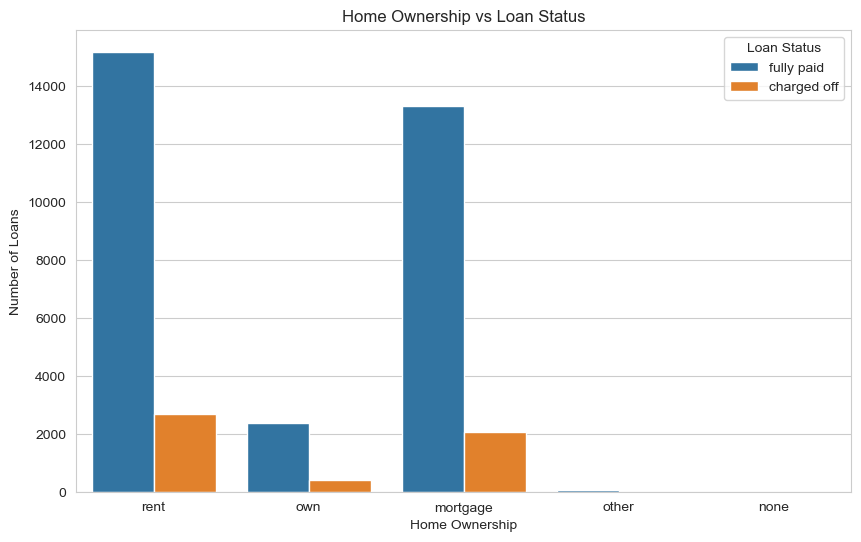

In [ ]:
sns.countplot(data=df, x="home_ownership", hue="loan_status")
plt.title("Home Ownership vs Loan Status")
plt.xlabel("Home Ownership")
plt.ylabel("Number of Loans")
plt.legend(title="Loan Status")
savefig("04_home_ownership_vs_loan_status.png")
plt.show()

### 5. Loan grade vs loan repayment

In [ ]:
df["grade"].value_counts()

grade
b    11043
a     9647
c     7411
d     4771
e     2326
f      811
g      189
Name: count, dtype: int64

In [ ]:
df.groupby(["grade", "loan_status"])["loan_status"].count()

grade  loan_status
a      charged off     593
       fully paid     9054
b      charged off    1360
       fully paid     9683
c      charged off    1297
       fully paid     6114
d      charged off    1057
       fully paid     3714
e      charged off     621
       fully paid     1705
f      charged off     252
       fully paid      559
g      charged off      61
       fully paid      128
Name: loan_status, dtype: int64

In [ ]:
grade_loan_status = df.groupby(["grade", "loan_status"])["loan_status"].count().unstack()

grade_loan_status

loan_status,charged off,fully paid
grade,,
a,593,9054
b,1360,9683
c,1297,6114
d,1057,3714
e,621,1705
f,252,559
g,61,128


In [ ]:
grade_loan_status["Total"] = (grade_loan_status["fully paid"] + grade_loan_status["charged off"])

grade_loan_status

loan_status,charged off,fully paid,Total
grade,,,
a,593,9054,9647
b,1360,9683,11043
c,1297,6114,7411
d,1057,3714,4771
e,621,1705,2326
f,252,559,811
g,61,128,189


In [ ]:
# approval percentage
grade_loan_status["Approval %"] = grade_loan_status["fully paid"] / grade_loan_status["Total"] * 100

grade_loan_status

loan_status,charged off,fully paid,Total,Approval %
grade,,,,
a,593,9054,9647,93.85
b,1360,9683,11043,87.68
c,1297,6114,7411,82.50
d,1057,3714,4771,77.85
e,621,1705,2326,73.30
f,252,559,811,68.93
g,61,128,189,67.72


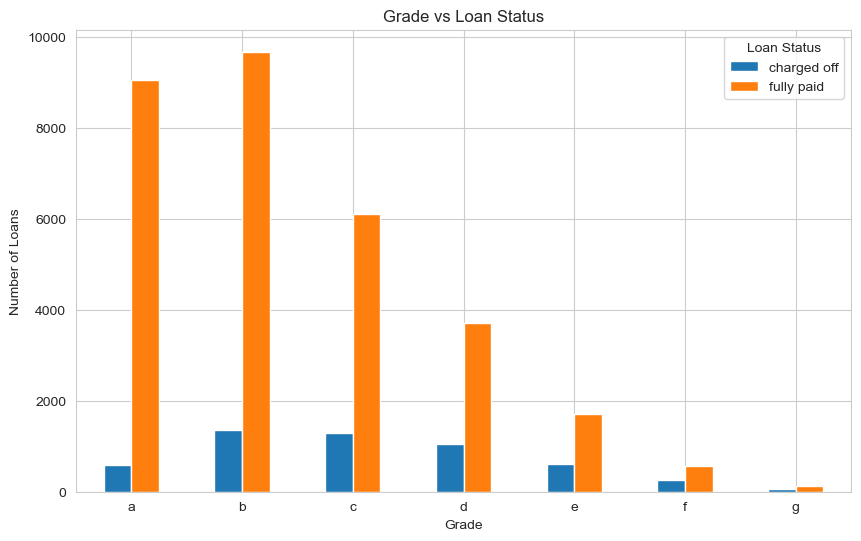

In [ ]:
order = sorted(df["grade"].unique())
ax = (
    df.groupby(["grade", "loan_status"])["loan_status"]
    .count()
    .unstack()
    .reindex(order)
    .plot(kind="bar")
)
plt.title("Grade vs Loan Status")
plt.xlabel("Grade")
plt.ylabel("Number of Loans")
plt.xticks(rotation=0)
plt.legend(title="Loan Status")
savefig("05_grade_vs_loan_status.png")
plt.show()

### 6. Interest rate vs loan repayment

In [ ]:
df["int_rate"].value_counts()

int_rate
10.99    856
7.51     769
11.49    754
7.88     705
13.49    698
        ... 
16.96      1
18.36      1
16.01      1
16.15      1
15.01      1
Name: count, Length: 357, dtype: int64

In [ ]:
df.groupby(["int_rate", "loan_status"])["loan_status"].count()

int_rate  loan_status
5.42      charged off     20
          fully paid     534
5.79      charged off     16
          fully paid     383
5.99      charged off     19
                        ... 
21.82     fully paid       1
22.06     charged off      8
          fully paid      13
22.11     charged off      9
          fully paid      12
Name: loan_status, Length: 666, dtype: int64

In [ ]:
int_rate_status = df.groupby(["int_rate", "loan_status"])["loan_status"].count().unstack().fillna(0)

int_rate_status

loan_status,charged off,fully paid
int_rate,,
5.42,20.00,534.00
5.79,16.00,383.00
5.99,19.00,318.00
6.00,0.00,16.00
6.03,5.00,425.00
...,...,...
21.67,12.00,15.00
21.74,14.00,8.00
21.82,1.00,1.00


In [ ]:
int_rate_status["Total"] = (int_rate_status["fully paid"] + int_rate_status["charged off"]).fillna(0)

int_rate_status

loan_status,charged off,fully paid,Total
int_rate,,,
5.42,20.00,534.00,554.00
5.79,16.00,383.00,399.00
5.99,19.00,318.00,337.00
6.00,0.00,16.00,16.00
6.03,5.00,425.00,430.00
...,...,...,...
21.67,12.00,15.00,27.00
21.74,14.00,8.00,22.00
21.82,1.00,1.00,2.00


In [ ]:
int_rate_status["Approval %"] = int_rate_status["fully paid"] / int_rate_status["Total"] * 100

int_rate_status

loan_status,charged off,fully paid,Total,Approval %
int_rate,,,,
5.42,20.00,534.00,554.00,96.39
5.79,16.00,383.00,399.00,95.99
5.99,19.00,318.00,337.00,94.36
6.00,0.00,16.00,16.00,100.00
6.03,5.00,425.00,430.00,98.84
...,...,...,...,...
21.67,12.00,15.00,27.00,55.56
21.74,14.00,8.00,22.00,36.36
21.82,1.00,1.00,2.00,50.00


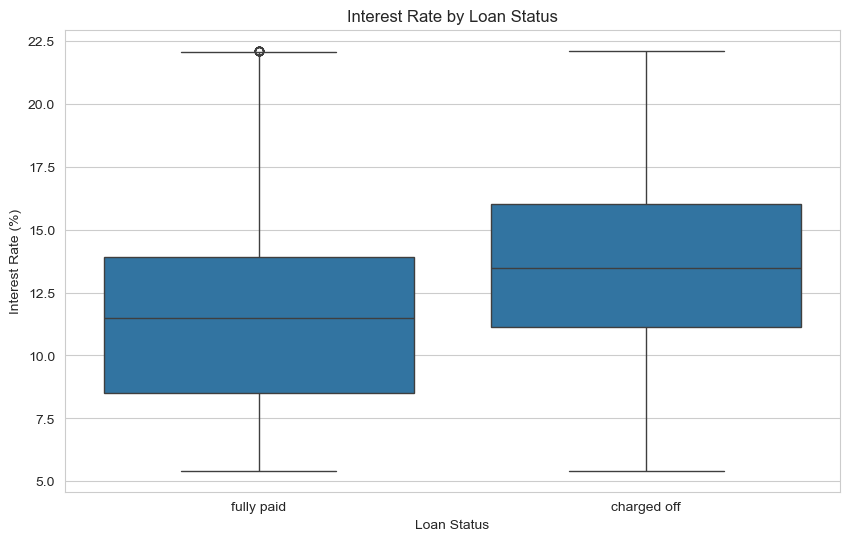

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="loan_status", y="int_rate")
plt.title("Interest Rate by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate (%)")
savefig("06_interest_rate_vs_loan_status.png")
plt.show()

### 7. Loan purpose vs loan repayment

In [ ]:
df["purpose"].value_counts()

purpose
debt_consolidation    17007
credit_card            4736
other                  3676
home_improvement       2536
major_purchase         2043
small_business         1566
car                    1455
wedding                 891
medical                 639
moving                  549
vacation                364
house                   330
educational             313
renewable_energy         93
Name: count, dtype: int64

In [ ]:
df.groupby(["purpose", "loan_status"])["loan_status"].count()

purpose             loan_status
car                 charged off      158
                    fully paid      1297
credit_card         charged off      506
                    fully paid      4230
debt_consolidation  charged off     2570
                    fully paid     14437
educational         charged off       54
                    fully paid       259
home_improvement    charged off      314
                    fully paid      2222
house               charged off       52
                    fully paid       278
major_purchase      charged off      216
                    fully paid      1827
medical             charged off      102
                    fully paid       537
moving              charged off       90
                    fully paid       459
other               charged off      595
                    fully paid      3081
renewable_energy    charged off       17
                    fully paid        76
small_business      charged off      424
                    fully

In [ ]:
purpose_loan_status = df.groupby(["purpose", "loan_status"])["loan_status"].count().unstack()

purpose_loan_status

loan_status,charged off,fully paid
purpose,,
car,158,1297
credit_card,506,4230
debt_consolidation,2570,14437
educational,54,259
home_improvement,314,2222
house,52,278
major_purchase,216,1827
medical,102,537
moving,90,459


In [ ]:
purpose_loan_status["Total"] = (purpose_loan_status["charged off"] + purpose_loan_status["fully paid"])

purpose_loan_status

loan_status,charged off,fully paid,Total
purpose,,,
car,158,1297,1455
credit_card,506,4230,4736
debt_consolidation,2570,14437,17007
educational,54,259,313
home_improvement,314,2222,2536
house,52,278,330
major_purchase,216,1827,2043
medical,102,537,639
moving,90,459,549


In [ ]:
purpose_loan_status["Approve %"] = purpose_loan_status["fully paid"] / purpose_loan_status["Total"] * 100

purpose_loan_status

loan_status,charged off,fully paid,Total,Approve %
purpose,,,,
car,158,1297,1455,89.14
credit_card,506,4230,4736,89.32
debt_consolidation,2570,14437,17007,84.89
educational,54,259,313,82.75
home_improvement,314,2222,2536,87.62
house,52,278,330,84.24
major_purchase,216,1827,2043,89.43
medical,102,537,639,84.04
moving,90,459,549,83.61


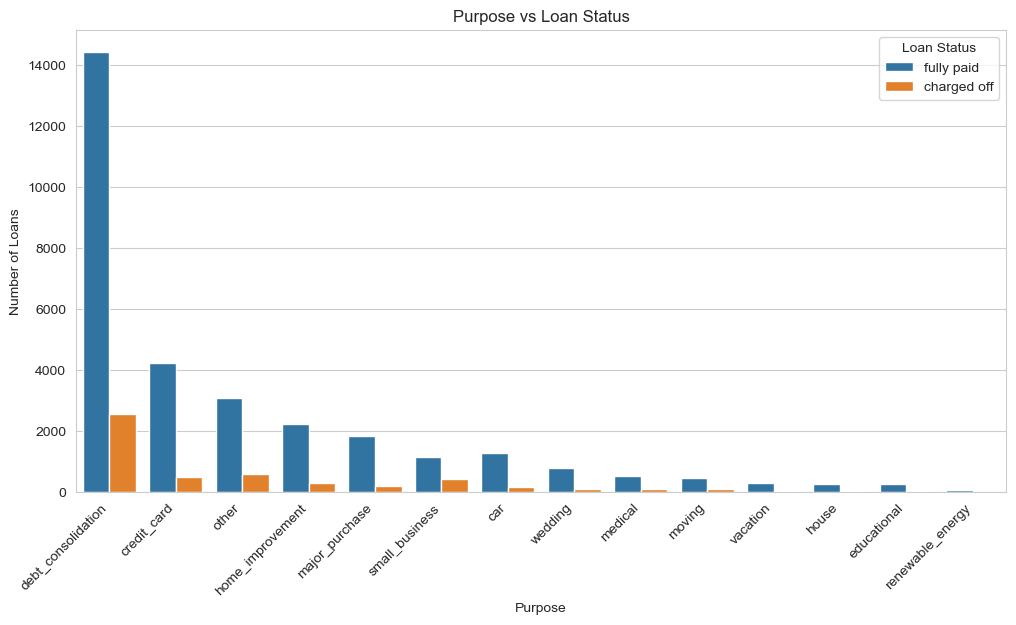

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x="purpose", hue="loan_status",
                    order=df["purpose"].value_counts().index)
plt.title("Purpose vs Loan Status")
plt.xlabel("Purpose")
plt.ylabel("Number of Loans")
plt.legend(title="Loan Status")
plt.xticks(rotation=45, ha="right")
savefig("07_purpose_vs_loan_status.png")
plt.show()

### 8. Which states have the highest default counts?

In [ ]:
df["addr_state"].value_counts()

addr_state
ca    6483
ny    3419
fl    2624
tx    2443
nj    1646
pa    1409
il    1384
va    1284
ga    1279
ma    1206
oh    1127
md     955
az     805
wa     777
co     728
nc     704
mi     672
ct     663
mo     640
mn     582
nv     451
sc     435
or     426
wi     418
al     411
la     399
ky     300
ok     277
ks     241
ut     238
ar     227
dc     192
ri     187
nm     177
wv     165
hi     158
nh     155
de     108
mt      81
wy      78
ak      66
sd      62
vt      52
ms      19
tn      17
in       9
id       6
ia       5
ne       5
me       3
Name: count, dtype: int64

In [ ]:
df.groupby(["addr_state", "loan_status"])["loan_status"].count()

addr_state  loan_status
ak          charged off     12
            fully paid      54
al          charged off     48
            fully paid     363
ar          charged off     26
                          ... 
wi          fully paid     359
wv          charged off     20
            fully paid     145
wy          charged off      3
            fully paid      75
Name: loan_status, Length: 97, dtype: int64

In [ ]:
state_add_loan_status = df.groupby(["addr_state", "loan_status"])["loan_status"].count().unstack().fillna(0)

state_add_loan_status

loan_status,charged off,fully paid
addr_state,,
ak,12.00,54.00
al,48.00,363.00
ar,26.00,201.00
az,115.00,690.00
ca,1046.00,5437.00
co,91.00,637.00
ct,89.00,574.00
dc,11.00,181.00
de,12.00,96.00


In [ ]:
state_add_loan_status["Total"] = (state_add_loan_status["fully paid"] + state_add_loan_status["charged off"])

state_add_loan_status

loan_status,charged off,fully paid,Total
addr_state,,,
ak,12.00,54.00,66.00
al,48.00,363.00,411.00
ar,26.00,201.00,227.00
az,115.00,690.00,805.00
ca,1046.00,5437.00,6483.00
co,91.00,637.00,728.00
ct,89.00,574.00,663.00
dc,11.00,181.00,192.00
de,12.00,96.00,108.00


In [ ]:
state_add_loan_status["Approved %"] = state_add_loan_status["fully paid"] / state_add_loan_status["Total"] * 100

state_add_loan_status

loan_status,charged off,fully paid,Total,Approved %
addr_state,,,,
ak,12.00,54.00,66.00,81.82
al,48.00,363.00,411.00,88.32
ar,26.00,201.00,227.00,88.55
az,115.00,690.00,805.00,85.71
ca,1046.00,5437.00,6483.00,83.87
co,91.00,637.00,728.00,87.50
ct,89.00,574.00,663.00,86.58
dc,11.00,181.00,192.00,94.27
de,12.00,96.00,108.00,88.89


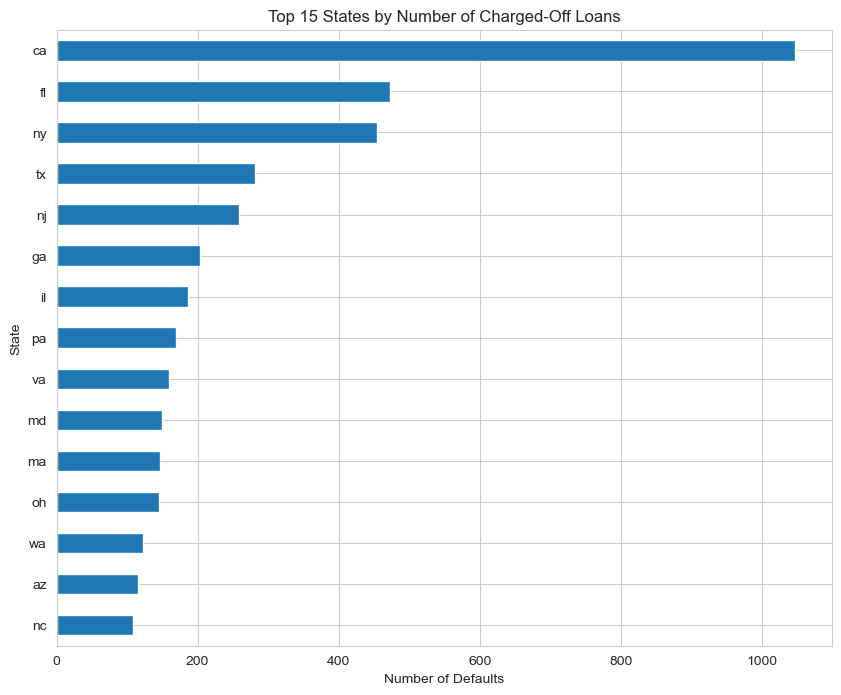

In [ ]:
default_by_state = (
    df[df["loan_status"] == "charged off"]
    .groupby("addr_state")
    .size()
    .sort_values(ascending=True)
    .tail(15)
)

plt.figure(figsize=(10, 8))
default_by_state.plot(kind="barh")
plt.title("Top 15 States by Number of Charged-Off Loans")
plt.xlabel("Number of Defaults")
plt.ylabel("State")
savefig("08_top_states_by_defaults.png")
plt.show()

### 9. Distributions: loan amount & interest rate

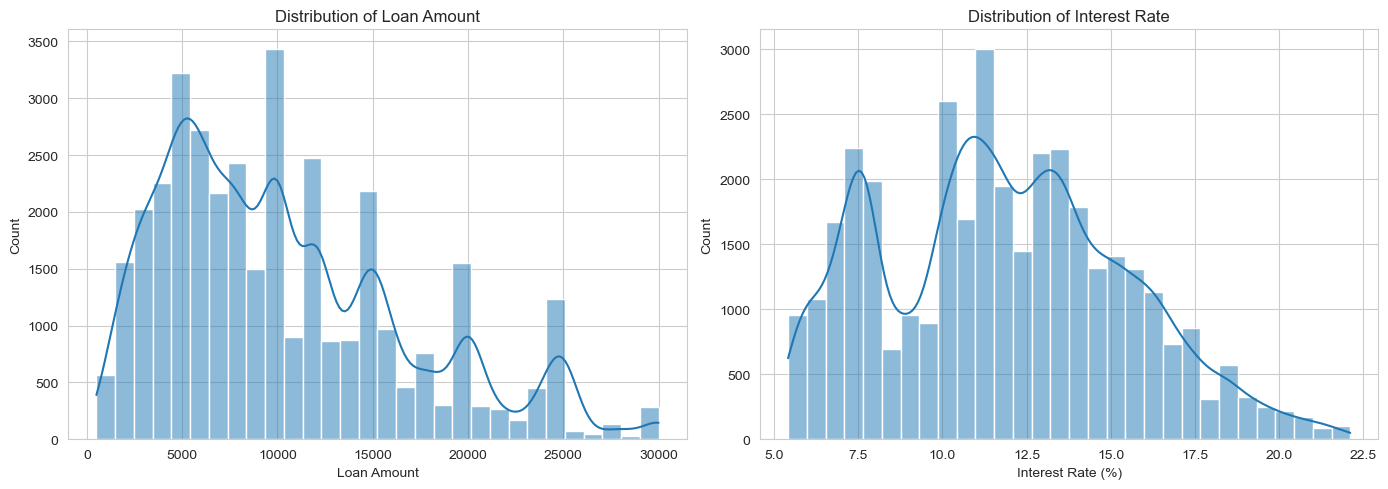

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["loan_amnt"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Loan Amount")
axes[0].set_xlabel("Loan Amount")

sns.histplot(df["int_rate"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Interest Rate")
axes[1].set_xlabel("Interest Rate (%)")

plt.tight_layout()
savefig("09_loan_amount_interest_rate_distribution.png")
plt.show()

### 10. Correlation among numeric features

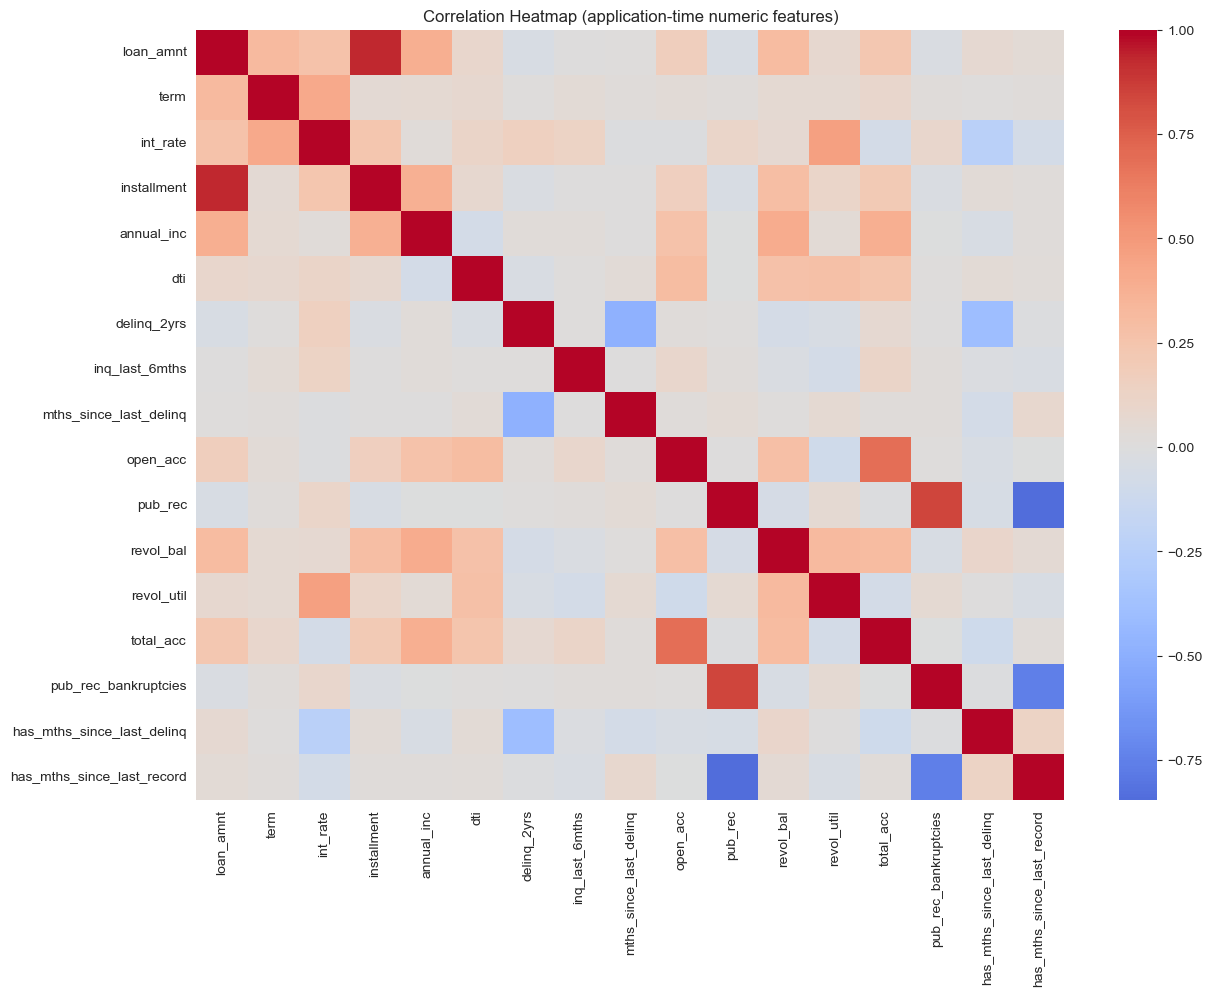

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (application-time numeric features)")
savefig("10_correlation_heatmap.png")
plt.show()

### 11. Loan volume over time

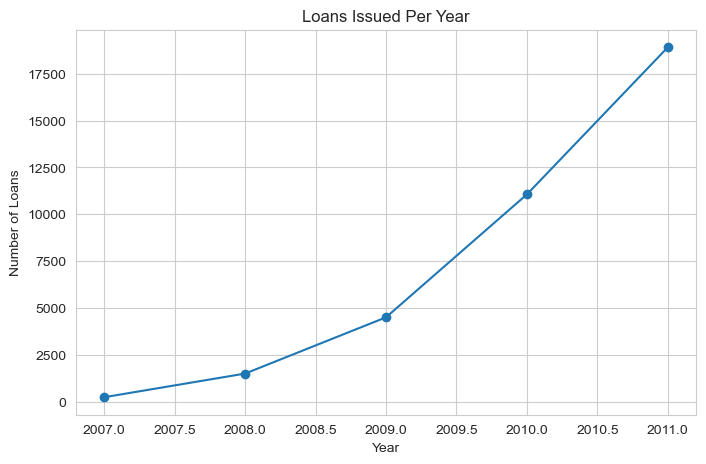

In [ ]:
loan_trend = df.groupby(df["issue_d"].dt.year).size().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(loan_trend.index, loan_trend.values, marker="o")
plt.title("Loans Issued Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Loans")
savefig("11_loans_issued_per_year.png")
plt.show()

# **SECTION 3: FEATURE ENGINEERING**
1. Encode the target (`loan_status`) as binary: `Fully Paid` = 0, `Charged Off` = 1
2. Employment length -> numeric years
3. Credit history length (`issue_d` - `earliest_cr_line`, in years)
4. Loan-to-income ratio & monthly income
5. Income category (Low / Medium / High, via `qcut`)
6. Extract issue year / month

#### Encode the target

In [ ]:
df["loan_status"].value_counts()

loan_status
fully paid     30957
charged off     5241
Name: count, dtype: int64

In [ ]:
df["loan_status"] = df["loan_status"].map({"fully paid": 0, "charged off": 1})
df["loan_status"].value_counts(normalize=True)

loan_status
0   0.86
1   0.14
Name: proportion, dtype: float64

#### Employment length -> numeric years

In [ ]:
emp_length_map = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10,
}
df["emp_length_years"] = df["emp_length"].map(emp_length_map)
df["emp_length_years"] = df["emp_length_years"].fillna(df["emp_length_years"].median())

df["employment_category"] = pd.cut(
    df["emp_length_years"], bins=[-1, 2, 6, 10], labels=["New", "Mid", "Experienced"]
).astype(str)

df[["emp_length", "emp_length_years", "employment_category"]].head()

,emp_length,emp_length_years,employment_category
0,10+ years,10,Experienced
1,< 1 year,0,New
2,10+ years,10,Experienced
3,10+ years,10,Experienced
5,3 years,3,Mid


#### Credit history length

In [ ]:
df["credit_history_years"] = df["issue_d"].dt.year - df["earliest_cr_line"].dt.year
df["credit_history_years"] = df["credit_history_years"].clip(lower=0)
df["credit_history_years"] = df["credit_history_years"].fillna(df["credit_history_years"].median())
df["credit_history_years"].describe()

count   36198.00
mean       13.36
std         6.61
min         0.00
25%         9.00
50%        12.00
75%        17.00
max        42.00
Name: credit_history_years, dtype: float64

#### Loan-to-income ratio & monthly income

In [ ]:
df["loan_income_ratio"] = df["loan_amnt"] / df["annual_inc"].replace(0, np.nan)
df["loan_income_ratio"] = df["loan_income_ratio"].fillna(df["loan_income_ratio"].median())

df["monthly_income"] = df["annual_inc"] / 12

df[["loan_amnt", "annual_inc", "loan_income_ratio", "monthly_income"]].head()

,loan_amnt,annual_inc,loan_income_ratio,monthly_income
0,5000,24000.00,0.21,2000.00
1,2500,30000.00,0.08,2500.00
2,2400,12252.00,0.20,1021.00
3,10000,49200.00,0.20,4100.00
5,5000,36000.00,0.14,3000.00


#### Income category

In [ ]:
df["income_category"], income_bins = pd.qcut(
    df["annual_inc"], q=3, labels=["Low", "Medium", "High"], retbins=True
)
df["income_category"] = df["income_category"].astype(str)

print("Income bin edges (for consistent use at inference time):", income_bins)
df[["annual_inc", "income_category"]].head()

Income bin edges (for consistent use at inference time): [  4000.  45000.  69600. 145000.]


,annual_inc,income_category
0,24000.00,Low
1,30000.00,Low
2,12252.00,Low
3,49200.00,Medium
5,36000.00,Low


#### Issue year / month

In [ ]:
df["issue_year"] = df["issue_d"].dt.year
df["issue_month"] = df["issue_d"].dt.month

df[["issue_d", "issue_year", "issue_month"]].head()

,issue_d,issue_year,issue_month
0,2011-12-01,2011,12
1,2011-12-01,2011,12
2,2011-12-01,2011,12
3,2011-12-01,2011,12
5,2011-12-01,2011,12


#### Quick look: which numeric features correlate most with the (now leakage-free) target?

In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
target_corr = numeric_df.corr(numeric_only=True)["loan_status"].sort_values(ascending=False)
target_corr

loan_status                   1.00
int_rate                      0.20
term                          0.17
loan_income_ratio             0.11
revol_util                    0.10
inq_last_6mths                0.07
pub_rec                       0.05
loan_amnt                     0.05
pub_rec_bankruptcies          0.05
dti                           0.04
emp_length_years              0.02
delinq_2yrs                   0.02
installment                   0.02
revol_bal                     0.01
mths_since_last_delinq        0.01
open_acc                     -0.01
total_acc                    -0.02
has_mths_since_last_delinq   -0.02
has_mths_since_last_record   -0.05
annual_inc                   -0.07
monthly_income               -0.07
Name: loan_status, dtype: float64

# **SECTION 4: MODEL TRAINING & EVALUATION**
1. Train / test split
2. Encoding + scaling (fit only on the training set, inside a `Pipeline`, to avoid leakage)
3. Model training (Logistic Regression, Random Forest, XGBoost)
4. Model evaluation (accuracy, precision, recall, F1, ROC AUC, confusion matrix, ROC curve)
5. Model comparison
6. Save models & reports

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

#### Feature lists
Only features that are known **at the time of loan application** are included - no post-outcome columns.

In [ ]:
NUMERIC_FEATURES = [
    "loan_amnt", "term", "int_rate", "installment", "annual_inc", "dti",
    "delinq_2yrs", "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
    "pub_rec_bankruptcies", "has_mths_since_last_delinq", "mths_since_last_delinq", "has_mths_since_last_record",
    "emp_length_years", "credit_history_years", "loan_income_ratio", "monthly_income",
    "issue_year", "issue_month",
]

CATEGORICAL_FEATURES = [
    "grade", "sub_grade", "home_ownership", "verification_status", "purpose", "addr_state",
    "employment_category", "income_category",
]

# every listed feature must actually exist in df
missing_features = [c for c in NUMERIC_FEATURES + CATEGORICAL_FEATURES if c not in df.columns]
assert not missing_features, f"Missing engineered columns: {missing_features}"

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
print(f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical = {len(FEATURES)} total features")

23 numeric + 8 categorical = 31 total features


#### Train / test split

In [ ]:
X = df[FEATURES].copy()
y = df["loan_status"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))

Train: (28958, 31)  Test: (7240, 31)
Train class balance:
 loan_status
0   0.85
1   0.14
Name: proportion, dtype: float64


#### Preprocessing pipeline (encoding + scaling)
Numeric features are median-imputed and standard-scaled; categorical features are mode-imputed and one-hot encoded.
This whole preprocessor is fit **only on the training set** and then applied to both train and test - this is what
prevents information from the test set (or the future) from leaking into training.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), NUMERIC_FEATURES),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL_FEATURES),
    ]
)

#### Model definitions

In [ ]:
# Roughly account for class imbalance (Charged Off is the minority class)
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print(f"scale_pos_weight (for XGBoost): {scale_pos_weight:.2f}")

models = {
    "LogisticRegression": LogisticRegression(
        random_state=42, max_iter=1000, class_weight="balanced"
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=20,
        random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    "XGBoost": XGBClassifier(
        random_state=42, eval_metric="logloss", n_estimators=300,
        scale_pos_weight=scale_pos_weight,
    ),
}

scale_pos_weight (for XGBoost): 5.91


#### Train, predict & evaluate
Each model is wrapped together with the `preprocessor` in a single `Pipeline`, so `.fit()` on raw training features
handles imputation, encoding, and scaling internally - and consistently - for both training and inference.

In [ ]:
results = []
trained_pipelines = {}

for model_name, model in models.items():
    print("=" * 80)
    print(f"Training {model_name}")
    print("=" * 80)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[model_name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_prob)
    cm        = confusion_matrix(y_test, y_pred)
    report    = classification_report(y_test, y_pred, zero_division=0)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}\n")
    print(report)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
        "Confusion Matrix": cm,
        "Classification Report": report,
        "FPR": fpr,
        "TPR": tpr,
    })

Training LogisticRegression
Accuracy : 0.6461
Precision: 0.2353
Recall   : 0.6422
F1 Score : 0.3444
ROC AUC  : 0.7021

              precision    recall  f1-score   support

           0       0.91      0.65      0.76      6192
           1       0.24      0.64      0.34      1048

    accuracy                           0.65      7240
   macro avg       0.57      0.64      0.55      7240
weighted avg       0.82      0.65      0.70      7240

Training RandomForest
Accuracy : 0.6809
Precision: 0.2478
Recall   : 0.5916
F1 Score : 0.3493
ROC AUC  : 0.6980

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      6192
           1       0.25      0.59      0.35      1048

    accuracy                           0.68      7240
   macro avg       0.58      0.64      0.57      7240
weighted avg       0.81      0.68      0.73      7240

Training XGBoost
Accuracy : 0.7920
Precision: 0.2755
Recall   : 0.2681
F1 Score : 0.2718
ROC AUC  : 0.6530

      

Accuracy : 0.6809
Precision: 0.2478
Recall   : 0.5916
F1 Score : 0.3493
ROC AUC  : 0.6980

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      6192
           1       0.25      0.59      0.35      1048

    accuracy                           0.68      7240
   macro avg       0.58      0.64      0.57      7240
weighted avg       0.81      0.68      0.73      7240

Training XGBoost


Accuracy : 0.7844
Precision: 0.2605
Recall   : 0.2662
F1 Score : 0.2633
ROC AUC  : 0.6523

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      6192
           1       0.26      0.27      0.26      1048

    accuracy                           0.78      7240
   macro avg       0.57      0.57      0.57      7240
weighted avg       0.79      0.78      0.79      7240



#### Model comparison table

In [ ]:
results_df = pd.DataFrame(results)
results_df_display = (
    results_df.drop(columns=["Confusion Matrix", "Classification Report", "FPR", "TPR"])
    .sort_values(by="ROC AUC", ascending=False)
    .reset_index(drop=True)
)
results_df_display

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.65,0.24,0.64,0.34,0.70
1,RandomForest,0.68,0.25,0.59,0.35,0.70
2,XGBoost,0.79,0.28,0.27,0.27,0.65


#### Confusion matrix & ROC curve for each model (saved to `reports/`)

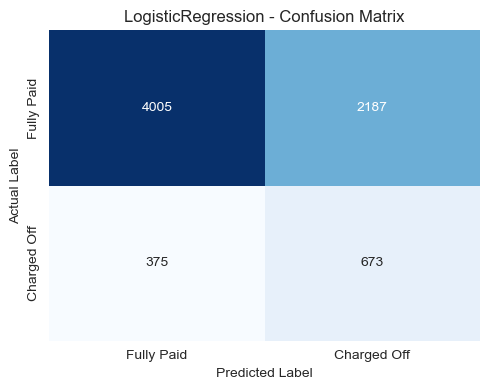

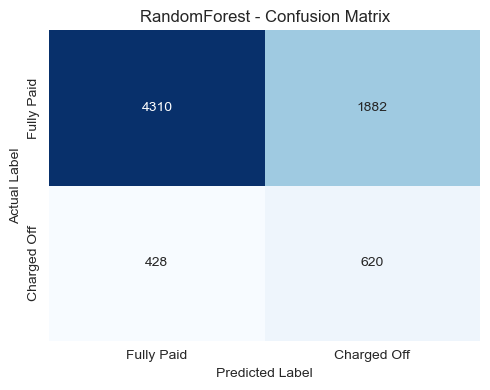

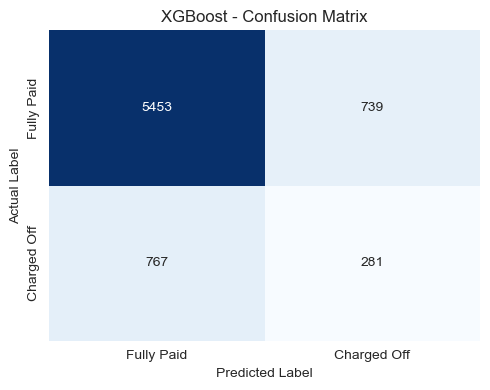

In [ ]:
for result in results:
    model_name = result["Model"]
    cm = result["Confusion Matrix"]

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Fully Paid", "Charged Off"],
                yticklabels=["Fully Paid", "Charged Off"])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"confusion_matrix_{model_name}.png", dpi=200)
    plt.show()

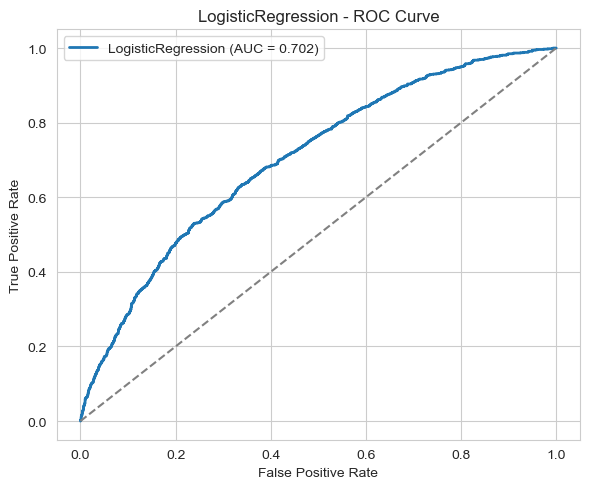

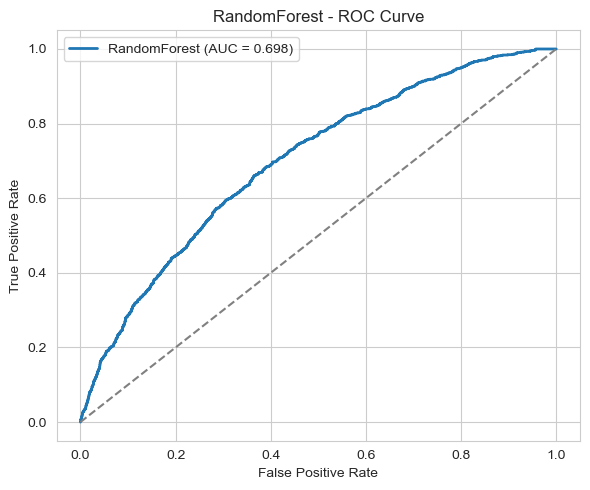

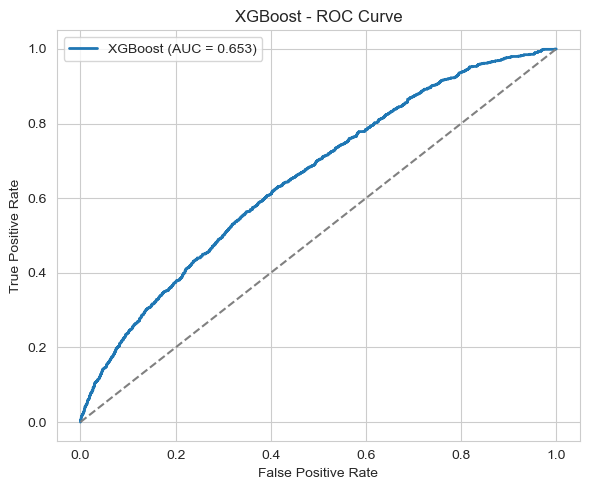

In [ ]:
for result in results:
    model_name = result["Model"]
    fpr, tpr, roc_auc = result["FPR"], result["TPR"], result["ROC AUC"]

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"roc_curve_{model_name}.png", dpi=200)
    plt.show()

#### Save classification reports & model comparison table

In [ ]:
for result in results:
    model_name = result["Model"]
    with open(REPORTS_DIR / f"{model_name}_classification_report.txt", "w") as f:
        f.write(result["Classification Report"])

results_df_display.to_csv(REPORTS_DIR / "model_report.csv", index=False)
print("Saved model_report.csv and per-model classification reports to reports/")

Saved model_report.csv and per-model classification reports to reports/


#### Model comparison chart

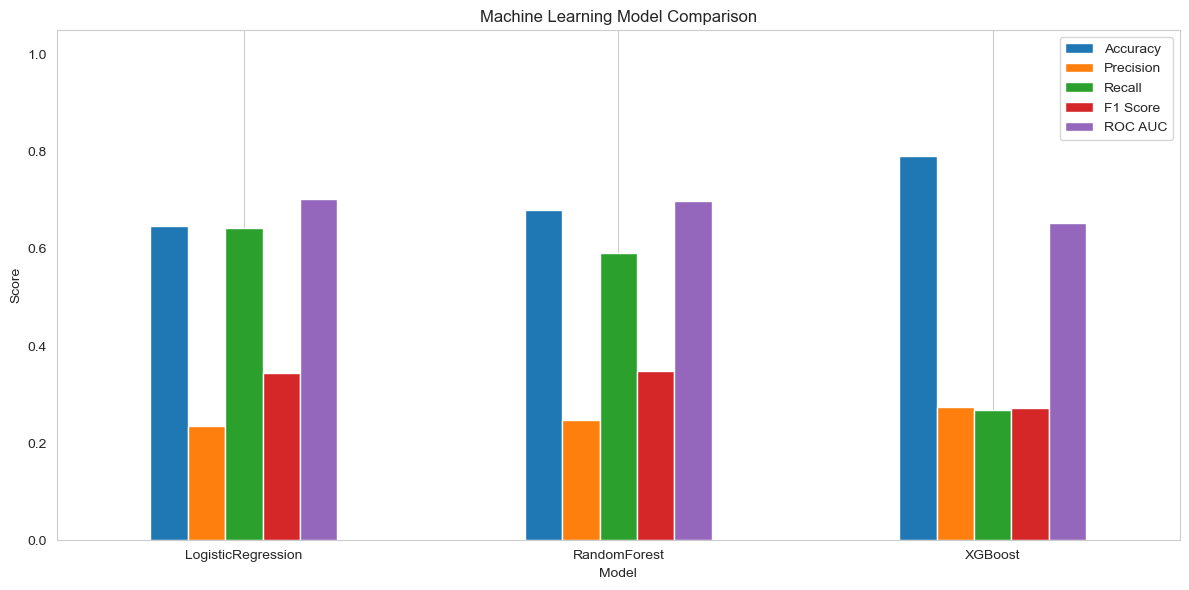

In [ ]:
comparison = results_df_display.set_index("Model")

comparison[["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]].plot(
    kind="bar", figsize=(12, 6)
)
plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_comparison.png", dpi=200)
plt.show()

#### Save all trained models

In [ ]:
for model_name, pipe in trained_pipelines.items():
    joblib.dump(pipe, MODELS_DIR / f"{model_name}.pkl")
    print(f"Saved {model_name}.pkl")

Saved LogisticRegression.pkl
Saved RandomForest.pkl
Saved XGBoost.pkl


In [ ]:
best_model_name = results_df_display.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

joblib.dump(best_pipeline, MODELS_DIR / "best_model.pkl")

with open(REPORTS_DIR / "best_model.txt", "w") as f:
    f.write(f"{best_model_name}\nROC AUC: {results_df_display.iloc[0]['ROC AUC']:.4f}")

print(f"Best model: {best_model_name} (ROC AUC = {results_df_display.iloc[0]['ROC AUC']:.4f})")
print("Saved as models/best_model.pkl")

Best model: LogisticRegression (ROC AUC = 0.7021)
Saved as models/best_model.pkl


In [ ]:
joblib.dump(FEATURES, MODELS_DIR / "feature_names.pkl")

print("Files in models/:")
for f in sorted(os.listdir(MODELS_DIR)):
    print(" -", f)

print("\nFiles in reports/:")
for f in sorted(os.listdir(REPORTS_DIR)):
    print(" -", f)
joblib.dump(income_bins, MODELS_DIR / "income_bins.pkl")
print("Saved income_bins.pkl")

Files in models/:
 - LogisticRegression.pkl
 - RandomForest.pkl
 - XGBoost.pkl
 - best_model.pkl
 - feature_names.pkl
 - income_bins.pkl

Files in reports/:
 - LogisticRegression_classification_report.txt
 - RandomForest_classification_report.txt
 - XGBoost_classification_report.txt
 - best_model.txt
 - confusion_matrix_LogisticRegression.png
 - confusion_matrix_RandomForest.png
 - confusion_matrix_XGBoost.png
 - model_comparison.png
 - model_report.csv
 - roc_curve_LogisticRegression.png
 - roc_curve_RandomForest.png
 - roc_curve_XGBoost.png
Saved income_bins.pkl


#### Save the cleaned dataset

In [ ]:
df.to_csv(CLEAN_DIR / "cleaned_loan_data.csv", index=False)
print("Saved cleaned dataset to", CLEAN_DIR / "cleaned_loan_data.csv")
print("Shape:", df.shape)

Saved cleaned dataset to C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\Loan_Prediction_Project\clean_data\cleaned_loan_data.csv
Shape: (36198, 35)


# **SECTION 5: PREDICTION PIPELINE**
A standalone, reusable pipeline that takes a **raw loan application** (the fields known before a decision is made -
no post-outcome data) and returns a default probability using the saved `best_model.pkl`.

The same feature-engineering steps used during training (employment length mapping, credit history length, income
ratio/category, etc.) are replicated here so that inference stays perfectly consistent with training. This is written
to `script/predict.py` so it can be reused **outside** this notebook (e.g. in an API or batch job).

In [ ]:
predict_script = '''
"""
Loan Default Prediction - inference pipeline.

Loads a trained sklearn Pipeline (preprocessing + classifier) saved during training and exposes a
`LoanDefaultPredictor` class that turns a *raw* loan application (fields known before a decision is made)
into a default probability. Feature engineering here mirrors the training notebook exactly.

Usage:
    from predict import LoanDefaultPredictor

    predictor = LoanDefaultPredictor(model_path="models/best_model.pkl")
    result = predictor.predict(raw_application_dict)
    print(result)
"""

from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(__file__).resolve().parent.parent
MODELS_DIR = PROJECT_ROOT / "models"

EMP_LENGTH_MAP = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10,
}


class LoanDefaultPredictor:
    """Wraps a saved model pipeline + the exact feature engineering used at training time."""

    def __init__(self, model_path=None, models_dir=MODELS_DIR):
        self.models_dir = Path(models_dir)
        model_path = Path(model_path) if model_path else self.models_dir / "best_model.pkl"

        self.pipeline = joblib.load(model_path)
        self.feature_names = joblib.load(self.models_dir / "feature_names.pkl")
        self.income_bins = joblib.load(self.models_dir / "income_bins.pkl")

    # ------------------------------------------------------------------
    # Feature engineering (mirrors the training notebook, Sections 1 & 3)
    # ------------------------------------------------------------------
    def _parse_term(self, term):
        if isinstance(term, str):
            digits = "".join(ch for ch in term if ch.isdigit())
            return int(digits) if digits else np.nan
        return float(term)

    def _parse_percent(self, value):
        if isinstance(value, str):
            return float(value.replace("%", "").strip())
        return float(value)

    def _parse_date(self, value):
        if pd.isna(value):
            return pd.NaT
        if isinstance(value, (pd.Timestamp, datetime)):
            return pd.Timestamp(value)
        return pd.to_datetime(value, format="%b-%y", errors="coerce")

    def engineer_features(self, raw: dict) -> pd.DataFrame:
        r = dict(raw)  # shallow copy, do not mutate caller\'s dict

        term = self._parse_term(r.get("term", 36))
        int_rate = self._parse_percent(r.get("int_rate", 0))
        revol_util = self._parse_percent(r.get("revol_util", 0))

        issue_d = self._parse_date(r.get("issue_d", datetime.today()))
        earliest_cr_line = self._parse_date(r.get("earliest_cr_line"))

        emp_length_raw = r.get("emp_length", "0")
        emp_length_years = EMP_LENGTH_MAP.get(emp_length_raw, r.get("emp_length_years", 0))
        if emp_length_years is None:
            emp_length_years = 0

        if emp_length_years <= 2:
            employment_category = "New"
        elif emp_length_years <= 6:
            employment_category = "Mid"
        else:
            employment_category = "Experienced"

        credit_history_years = 0
        if pd.notna(issue_d) and pd.notna(earliest_cr_line):
            credit_history_years = max(issue_d.year - earliest_cr_line.year, 0)

        annual_inc = float(r.get("annual_inc", 0))
        loan_amnt = float(r.get("loan_amnt", 0))
        loan_income_ratio = loan_amnt / annual_inc if annual_inc else 0
        monthly_income = annual_inc / 12

        income_category = pd.cut(
            [annual_inc], bins=self.income_bins, labels=["Low", "Medium", "High"], include_lowest=True
        )[0]
        income_category = str(income_category) if pd.notna(income_category) else "Medium"

        mths_since_last_delinq = r.get("mths_since_last_delinq")
        has_mths_since_last_delinq = int(pd.isna(mths_since_last_delinq))

        features = {
            "loan_amnt": loan_amnt,
            "term": term,
            "int_rate": int_rate,
            "installment": float(r.get("installment", 0)),
            "annual_inc": annual_inc,
            "dti": float(r.get("dti", 0)),
            "delinq_2yrs": float(r.get("delinq_2yrs", 0)),
            "inq_last_6mths": float(r.get("inq_last_6mths", 0)),
            "open_acc": float(r.get("open_acc", 0)),
            "pub_rec": float(r.get("pub_rec", 0)),
            "revol_bal": float(r.get("revol_bal", 0)),
            "revol_util": revol_util,
            "total_acc": float(r.get("total_acc", 0)),
            "pub_rec_bankruptcies": float(r.get("pub_rec_bankruptcies", 0)),
            "has_mths_since_last_delinq": has_mths_since_last_delinq,
            "mths_since_last_delinq": float(mths_since_last_delinq) if mths_since_last_delinq is not None else 0,
            "has_mths_since_last_record": int(pd.isna(r.get("mths_since_last_record"))),
            "emp_length_years": emp_length_years,
            "credit_history_years": credit_history_years,
            "loan_income_ratio": loan_income_ratio,
            "monthly_income": monthly_income,
            "issue_year": issue_d.year if pd.notna(issue_d) else datetime.today().year,
            "issue_month": issue_d.month if pd.notna(issue_d) else datetime.today().month,
            "grade": r.get("grade", "c"),
            "sub_grade": r.get("sub_grade", "c1"),
            "home_ownership": r.get("home_ownership", "rent"),
            "verification_status": r.get("verification_status", "not verified"),
            "purpose": r.get("purpose", "debt_consolidation"),
            "addr_state": r.get("addr_state", "ca"),
            "initial_list_status": r.get("initial_list_status", "f"),
            "employment_category": employment_category,
            "income_category": income_category,
        }

        return pd.DataFrame([features])[self.feature_names]

    # ------------------------------------------------------------------
    def predict(self, raw: dict) -> dict:
        X = self.engineer_features(raw)
        proba_default = float(self.pipeline.predict_proba(X)[0, 1])
        prediction = "Charged Off" if proba_default >= 0.5 else "Fully Paid"

        return {
            "prediction": prediction,
            "probability_of_default": round(proba_default, 4),
            "probability_of_full_repayment": round(1 - proba_default, 4),
        }


if __name__ == "__main__":
    predictor = LoanDefaultPredictor()

    sample_application = {
        "loan_amnt": 12000, "term": "36 months", "int_rate": "13.5%", "installment": 407.5,
        "annual_inc": 55000, "dti": 18.2, "delinq_2yrs": 0, "inq_last_6mths": 1,
        "open_acc": 9, "pub_rec": 0, "revol_bal": 8000, "revol_util": "45%", "total_acc": 22,
        "pub_rec_bankruptcies": 0, "grade": "c", "sub_grade": "c2", "home_ownership": "rent",
        "verification_status": "verified", "purpose": "debt_consolidation", "addr_state": "ca",
        "initial_list_status": "f", "emp_length": "5 years",
        "issue_d": "Dec-11", "earliest_cr_line": "Jan-01",
    }

    result = predictor.predict(sample_application)
    print(result)
'''

script_path = SCRIPT_DIR / "predict.py"
script_path.write_text(predict_script)
print("Wrote prediction pipeline to", script_path)

Wrote prediction pipeline to C:\Users\Adams\Documents\Data Analysis class\Data Science Projects\Projects\Loan_Prediction_Project\script\predict.py


#### Try it out

In [ ]:
import sys
sys.path.insert(0, str(SCRIPT_DIR))

# reload in case predict.py already existed on the path from a previous run
import importlib
if "predict" in sys.modules:
    importlib.reload(sys.modules["predict"])
from predict import LoanDefaultPredictor

predictor = LoanDefaultPredictor(model_path=MODELS_DIR / "best_model.pkl")

In [ ]:
sample_applications = [
    {
        "loan_amnt": 12000, "term": "36 months", "int_rate": "13.5%", "installment": 407.5,
        "annual_inc": 55000, "dti": 18.2, "delinq_2yrs": 0, "inq_last_6mths": 1,
        "open_acc": 9, "pub_rec": 0, "revol_bal": 8000, "revol_util": "45%", "total_acc": 22,
        "pub_rec_bankruptcies": 0, "grade": "c", "sub_grade": "c2", "home_ownership": "rent",
        "verification_status": "verified", "purpose": "debt_consolidation", "addr_state": "ca",
        "initial_list_status": "f", "emp_length": "5 years",
        "issue_d": "Dec-11", "earliest_cr_line": "Jan-01",
    },
    {
        "loan_amnt": 30000, "term": "60 months", "int_rate": "22.8%", "installment": 837.9,
        "annual_inc": 32000, "dti": 34.5, "delinq_2yrs": 2, "inq_last_6mths": 4,
        "open_acc": 15, "pub_rec": 1, "revol_bal": 21000, "revol_util": "91%", "total_acc": 30,
        "pub_rec_bankruptcies": 1, "grade": "f", "sub_grade": "f3", "home_ownership": "rent",
        "verification_status": "verified", "purpose": "small_business", "addr_state": "fl",
        "initial_list_status": "f", "emp_length": "< 1 year",
        "issue_d": "Jun-12", "earliest_cr_line": "Mar-08",
    },
]

for i, application in enumerate(sample_applications, start=1):
    result = predictor.predict(application)
    print(f"Applicant {i}: {result}")

Applicant 1: {'prediction': 'Fully Paid', 'probability_of_default': 0.4987, 'probability_of_full_repayment': 0.5013}
Applicant 2: {'prediction': 'Charged Off', 'probability_of_default': 0.9708, 'probability_of_full_repayment': 0.0292}


#### Batch prediction on the held-out test set
As a final check, run the saved pipeline over the actual test split and confirm it reproduces the metrics from Section 4.

In [ ]:
from sklearn.metrics import roc_auc_score

test_probs = best_pipeline.predict_proba(X_test)[:, 1]
print("Best model:", best_model_name)
print("ROC AUC on held-out test set:", round(roc_auc_score(y_test, test_probs), 4))

Best model: LogisticRegression
ROC AUC on held-out test set: 0.7021


## **Summary**
- Removed post-outcome / leakage columns.
- Built a pipeline for encoding & scaling are fit **only** on the training split, inside a single `sklearn.Pipeline`
  per model - this is also what gets saved to `models/`, so there's no risk of preprocessing drifting from training.
- Trained and compared three models (Logistic Regression, Random Forest, XGBoost); the best one by ROC AUC is saved
  as `models/best_model.pkl`.
- All reports (`model_report.csv`, comparison chart, confusion matrices, ROC curves) are in `reports/`.
- A reusable, standalone inference pipeline lives in `script/predict.py`.